# Notebook 07: Genre Performance Across Platforms

## Research Question 5

**How does the performance of video game genres vary across different platforms?**

## Objective

This notebook examines how video game genres perform across gaming platforms.

Rather than evaluating genres or platforms independently, the analysis focuses on the relationship between them. This helps identify which genre-platform combinations generated the strongest sales and whether certain genres performed particularly well on specific platforms.

The analysis will consider both total global sales and the number of games released. Average sales per game will also be examined so that combinations with large game libraries are not automatically treated as the strongest performers.

## Analysis Overview

This notebook will examine:

1. The number of games released for each genre-platform combination
2. Total global sales by genre and platform
3. Average global sales per game
4. The strongest genre-platform combinations
5. Genre performance across selected major platforms
6. The balance between release volume and sales performance

The notebook will conclude with a brief interpretation of the main findings and how they contribute to the broader video game sales analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [2]:
candidate_paths = [
    Path("../../data/processed/video_game_sales_cleaned.csv"),
    Path("../data/processed/video_game_sales_cleaned.csv"),
    Path("data/processed/video_game_sales_cleaned.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find video_game_sales_cleaned.csv. "
        "Update candidate_paths to match the notebook's location."
    )

df = pd.read_csv(data_path)

print(f"Loaded: {data_path.resolve()}")
print(f"Dataset shape: {df.shape}")
df.head()

Loaded: C:\Users\tyler\OneDrive\Desktop\26projects\data_an\data-analysis-on-the-videogame-industry\data\processed\video_game_sales_cleaned.csv
Dataset shape: (16287, 19)


,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.501450,0.350737,0.045564,0.102248,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.722664,0.088966,0.169235,0.019135,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.442367,0.359475,0.105777,0.092381,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.477273,0.333636,0.099394,0.089697,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.359146,0.283301,0.325685,0.031867,North America


## Data Preparation

The cleaned dataset is loaded and reduced to the variables needed for this analysis:

- Game name
- Platform
- Genre
- Global sales

Rows missing platform, genre, or global sales information are excluded. Genre-platform combinations are then summarized using release count, total sales, average sales, and median sales.


In [3]:
analysis_df = df[
    ["name", "platform", "genre", "global_sales"]
].copy()

analysis_df = analysis_df.dropna(
    subset=["platform", "genre", "global_sales"]
)

print(f"Analysis dataset shape: {analysis_df.shape}")

analysis_df.head()

Analysis dataset shape: (16287, 4)


,name,platform,genre,global_sales
0,Wii Sports,Wii,Sports,82.74
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.82
3,Wii Sports Resort,Wii,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37


In [4]:
print(analysis_df.dtypes)

print(f"\nUnique platforms: {analysis_df['platform'].nunique()}")
print(f"Unique genres: {analysis_df['genre'].nunique()}")

name                str
platform            str
genre               str
global_sales    float64
dtype: object

Unique platforms: 31
Unique genres: 12


In [5]:
genre_platform_summary = (
    analysis_df
    .groupby(["platform", "genre"])
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median")
    )
    .reset_index()
)

genre_platform_summary.head(10).round(2)


,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
0,2600,Action,55,26.39,0.48,0.38
1,2600,Adventure,1,0.40,0.40,0.40
2,2600,Fighting,1,0.77,0.77,0.77
3,2600,Misc,5,3.58,0.72,0.87
4,2600,Platform,9,13.27,1.47,1.10
5,2600,Puzzle,8,13.65,1.71,0.68
6,2600,Racing,4,2.32,0.58,0.44
7,2600,Shooter,22,22.97,1.04,0.75
8,2600,Simulation,1,0.45,0.45,0.45
9,2600,Sports,10,2.77,0.28,0.24


## Strongest Genre–Platform Combinations

Some genre-platform combinations are represented by only a small number of games. A single unusually successful title could therefore produce a high average despite limited evidence.

A minimum threshold of 10 games is used as a practical safeguard against rankings being dominated by combinations represented by only a few titles. This threshold is not a formal statistical rule, but it improves the stability of the comparisons.


In [6]:
# Keep combinations with enough games for a more reliable comparison
minimum_games = 10

reliable_combinations = genre_platform_summary[
    genre_platform_summary["game_count"] >= minimum_games
].copy()

print(f"Genre-platform combinations with at least {minimum_games} games:")
print(reliable_combinations.shape[0])

Genre-platform combinations with at least 10 games:
207


### 1. Top Genre–Platform Combinations by Total Global Sales

The following chart shows the genre-platform combinations that generated the greatest total global sales.

This measure reflects overall commercial contribution, but it may favour combinations with a large number of game releases.

In [7]:
top_total_sales = (
    reliable_combinations
    .sort_values("total_global_sales", ascending=False)
    .head(15)
)

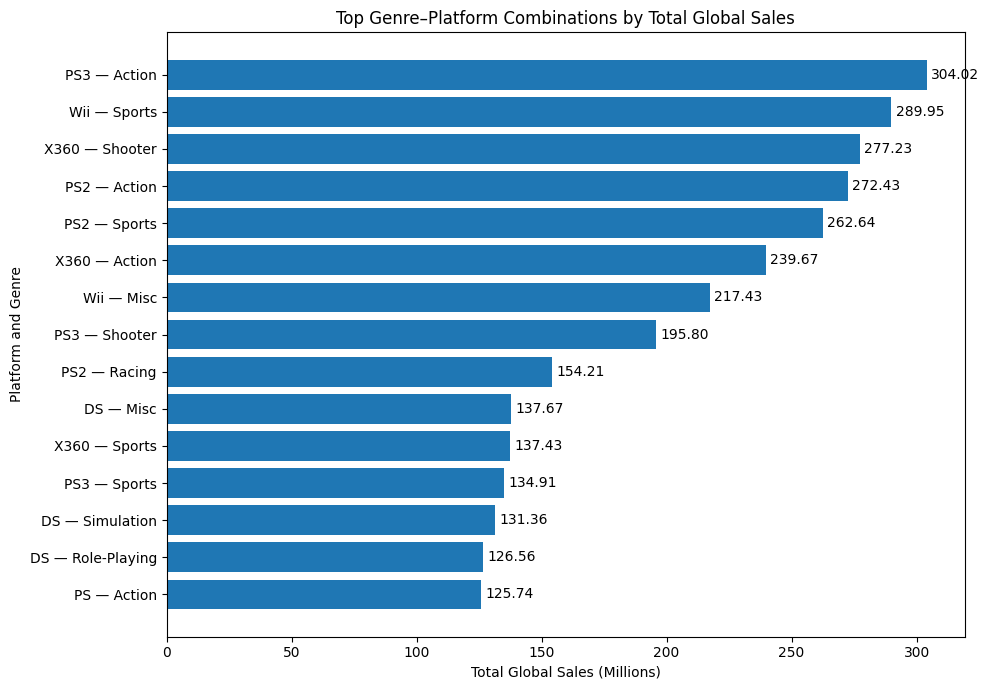

In [8]:
top_total_sales = top_total_sales.copy()

top_total_sales["genre_platform"] = (
    top_total_sales["platform"]
    + " — "
    + top_total_sales["genre"]
)

plot_data = top_total_sales.sort_values(
    "total_global_sales",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_data["genre_platform"],
    plot_data["total_global_sales"]
)

plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Top Genre–Platform Combinations by Total Global Sales")
plt.xlabel("Total Global Sales (Millions)")
plt.ylabel("Platform and Genre")

plt.tight_layout()
plt.show()

### Key Takeaway

The PS3–Action combination generated the highest total global sales at approximately **304.02 million**, followed by Wii–Sports at **289.95 million** and Xbox 360–Shooter at **277.23 million**. Action appears repeatedly across the top-ranked combinations, especially on the PS3, PS2, Xbox 360, and original PlayStation, indicating that the genre performed strongly across multiple platforms. However, the presence of Wii–Sports and Xbox 360–Shooter near the top also shows that the strongest genre depended on the platform rather than one genre dominating every system.

### 2. Top Genre–Platform Combinations by Average Global Sales

Total sales can be heavily influenced by the number of games released. Average global sales per game provides a different perspective by measuring the typical sales performance of each genre-platform combination.

Only combinations with at least 10 games are included to reduce the influence of small groups and individual blockbuster titles.

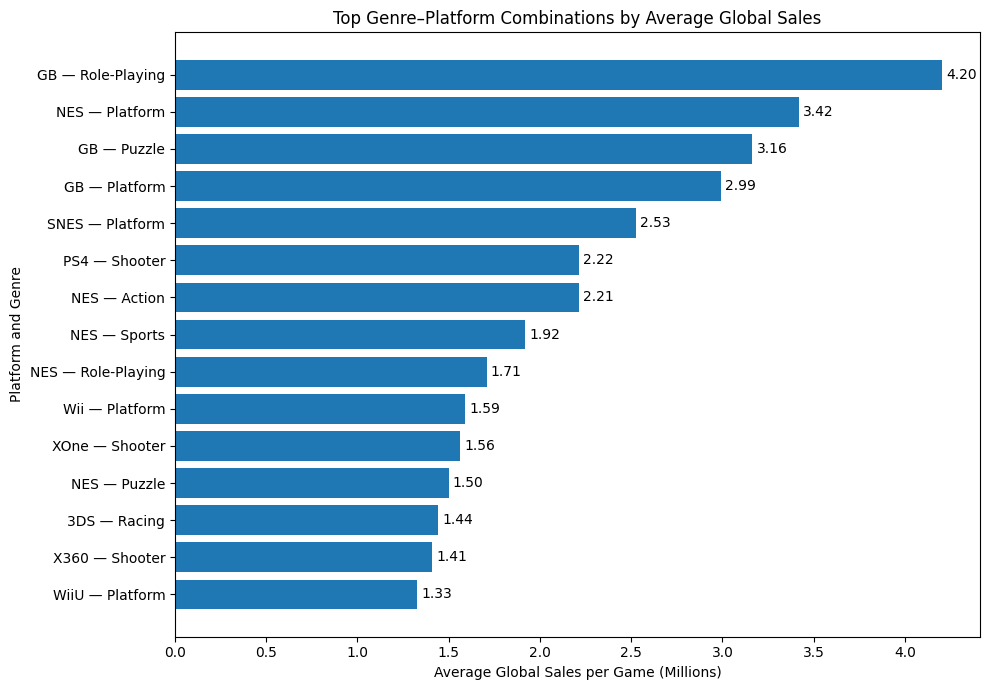

In [9]:
top_average_sales = (
    reliable_combinations
    .sort_values("average_global_sales", ascending=False)
    .head(15)
    .copy()
)

top_average_sales["genre_platform"] = (
    top_average_sales["platform"]
    + " — "
    + top_average_sales["genre"]
)

plot_data = top_average_sales.sort_values(
    "average_global_sales",
    ascending=True
)

plt.figure(figsize=(10, 7))

# Store the container returned by plt.barh
bars = plt.barh(
    plot_data["genre_platform"],
    plot_data["average_global_sales"]
)

# Add values next to the bars
plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Top Genre–Platform Combinations by Average Global Sales")
plt.xlabel("Average Global Sales per Game (Millions)")
plt.ylabel("Platform and Genre")

plt.tight_layout()
plt.show()

### Key Takeaway

The Game Boy–Role-Playing combination had the highest average global sales at approximately **4.20 million per game**, clearly exceeding every other genre-platform pairing. Platform games also performed especially well on older Nintendo systems, including the NES, Game Boy, and SNES. Compared with the total-sales ranking, this chart highlights that the combinations with the strongest per-game performance were not necessarily the ones with the largest overall sales totals.

### 3. Most Common Genre–Platform Combinations

The number of games released shows which genre-platform combinations were most heavily represented in the dataset.

Comparing release volume with total and average sales helps determine whether a combination's commercial performance was driven by a large catalogue or by stronger sales per individual game.

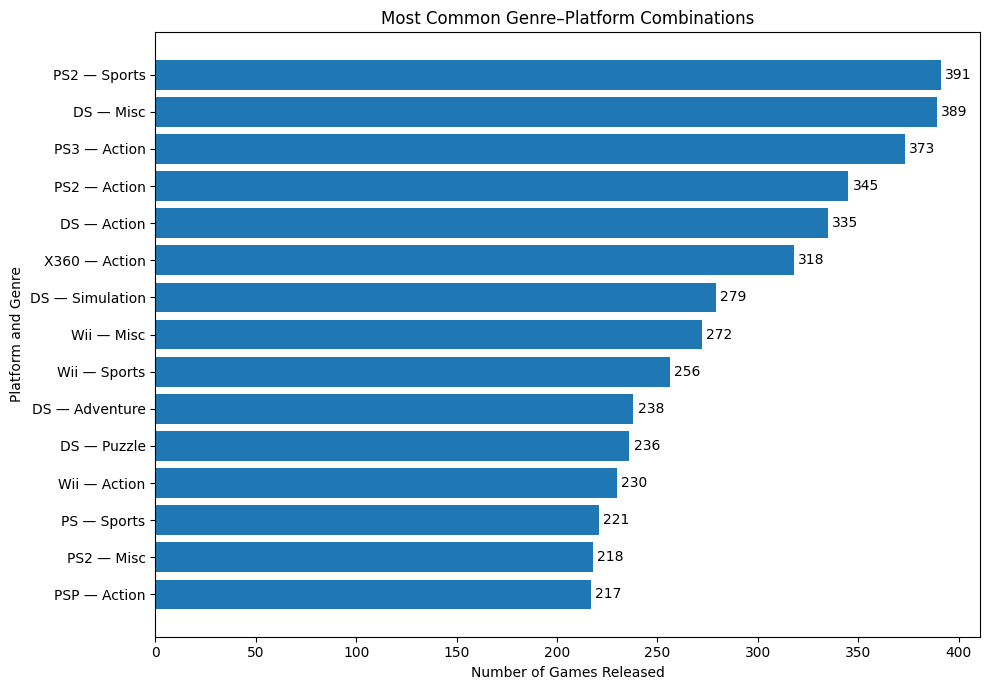

In [10]:
top_game_count = (
    reliable_combinations
    .sort_values("game_count", ascending=False)
    .head(15)
    .copy()
)

top_game_count["genre_platform"] = (
    top_game_count["platform"]
    + " — "
    + top_game_count["genre"]
)

plot_data = top_game_count.sort_values(
    "game_count",
    ascending=True
)

plt.figure(figsize=(10, 7))

# Store the bar container
bars = plt.barh(
    plot_data["genre_platform"],
    plot_data["game_count"]
)

# Add whole number labels next to the bars
plt.bar_label(bars, fmt="%d", padding=3)

plt.title("Most Common Genre–Platform Combinations")
plt.xlabel("Number of Games Released")
plt.ylabel("Platform and Genre")

plt.tight_layout()
plt.show()

### Key Takeaway

The PS2–Sports combination had the largest number of releases with **391 games**, narrowly ahead of DS–Misc with **389 games** and PS3–Action with **373 games**. Action appears frequently across several major platforms, including the PS3, PS2, DS, Xbox 360, Wii, and PSP, showing that it was one of the most widely produced genres. However, the combinations with the most releases were not always the same as those with the highest average sales, which suggests that release volume and per-game performance should be evaluated separately.

## 4. Comparison of Sales Volume and Sales Efficiency

The following table combines total sales, average sales, and release volume for the leading genre-platform combinations.

This comparison helps identify whether strong total sales were primarily associated with:

- A large number of releases
- High average sales per game
- A combination of both factors

In [11]:
comparison_table = (
    reliable_combinations
    .sort_values("total_global_sales", ascending=False)
    .head(20)
    [
        [
            "platform",
            "genre",
            "game_count",
            "total_global_sales",
            "average_global_sales",
            "median_global_sales"
        ]
    ]
)

comparison_table

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
153,PS3,Action,373,304.02,0.815067,0.320
244,Wii,Sports,256,289.95,1.132617,0.230
266,X360,Shooter,197,277.23,1.407259,0.410
141,PS2,Action,345,272.43,0.789652,0.360
151,PS2,Sports,391,262.64,0.671714,0.310
258,X360,Action,318,239.67,0.753679,0.295
237,Wii,Misc,272,217.43,0.799375,0.240
161,PS3,Shooter,155,195.80,1.263226,0.570
147,PS2,Racing,212,154.21,0.727406,0.260
37,DS,Misc,389,137.67,0.353907,0.100


## 5. Genre Performance Across Platforms

A heatmap provides a broader view of how genres performed across platforms.

The first heatmap compares total global sales. Darker cells represent genre-platform combinations with greater accumulated sales.

Because total sales are influenced by both game performance and the number of releases, this chart should be interpreted alongside the average-sales heatmap.

In [12]:
# Create a platform-by-genre table using total global sales
total_sales_pivot = (
    analysis_df
    .pivot_table(
        index="platform",
        columns="genre",
        values="global_sales",
        aggfunc="sum",
        fill_value=0
    )
)

# Rank platforms by total sales and keep the 15 largest
top_platforms = (
    analysis_df
    .groupby("platform")["global_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

total_sales_pivot = total_sales_pivot.loc[top_platforms]

total_sales_pivot.round(2)

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
platform,,,,,,,,,,,,
PS2,272.43,21.16,89.19,98.69,72.11,5.90,154.21,91.55,108.28,42.26,262.64,15.04
X360,239.67,15.23,37.64,89.33,11.39,0.71,65.13,71.97,277.23,14.10,137.43,9.77
PS3,304.02,22.87,51.70,45.91,29.85,0.46,73.10,75.24,195.80,10.72,134.91,4.77
Wii,110.48,18.33,23.82,217.43,90.68,15.63,61.24,14.06,26.34,36.62,289.95,5.23
DS,114.16,47.15,7.20,137.67,77.40,83.87,38.58,126.56,8.20,131.36,31.71,14.76
PS,125.74,20.77,72.68,44.90,64.21,12.08,102.89,78.30,39.31,25.33,119.51,21.67
GBA,54.26,12.10,4.21,28.50,78.08,12.09,18.80,64.21,3.60,5.91,16.41,7.45
PSP,62.66,10.69,21.88,13.70,17.28,5.52,34.73,49.01,19.77,6.28,39.90,10.29
PS4,87.06,4.70,8.04,7.40,7.01,0.02,11.53,25.74,75.32,0.77,50.07,0.41


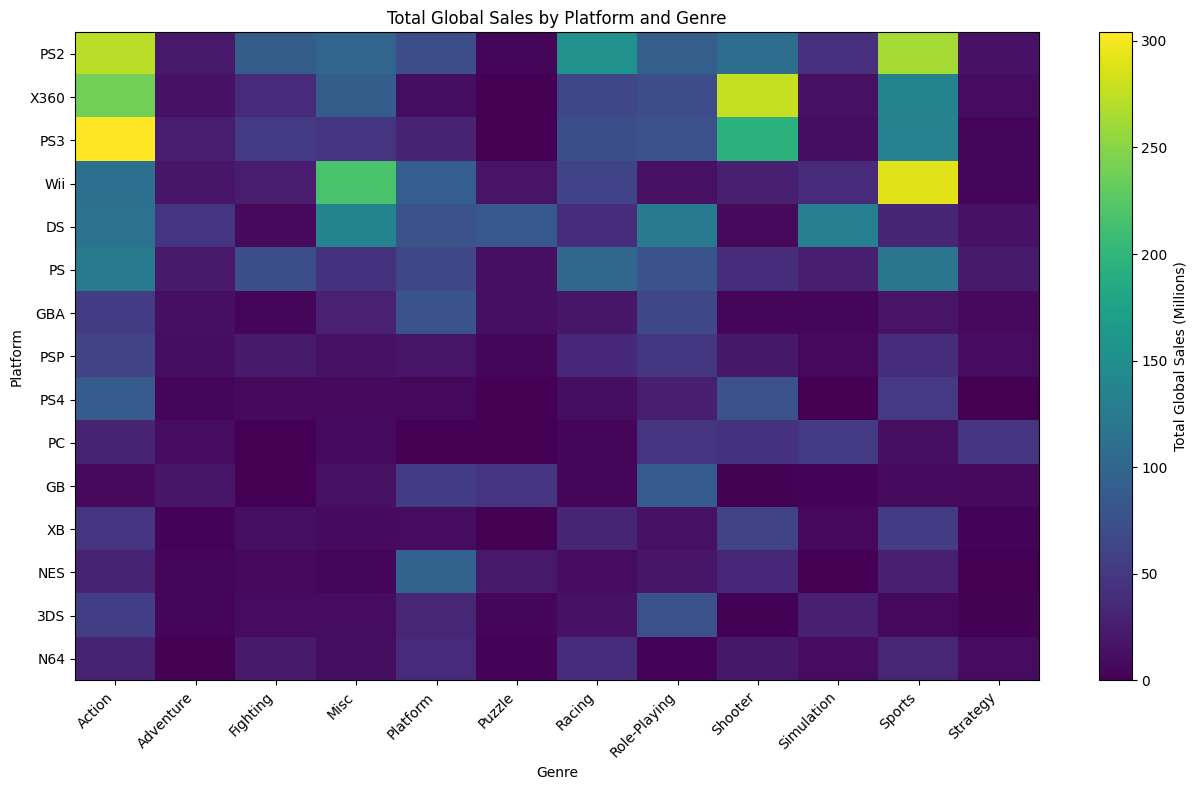

In [13]:
# Plot the total-sales heatmap using Matplotlib
fig, ax = plt.subplots(figsize=(13, 8))

heatmap = ax.imshow(
    total_sales_pivot.values,
    aspect="auto"
)

ax.set_xticks(range(len(total_sales_pivot.columns)))
ax.set_xticklabels(
    total_sales_pivot.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(total_sales_pivot.index)))
ax.set_yticklabels(total_sales_pivot.index)

ax.set_title("Total Global Sales by Platform and Genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Platform")

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Total Global Sales (Millions)")

plt.tight_layout()
plt.show()

### Key Takeaway

The heatmap shows that genre performance varied substantially by platform rather than following one consistent pattern across all systems. Action produced especially high total sales on the PS3, while Sports was strongest on the Wii and Shooter stood out on the Xbox 360. The PS2 showed strong sales across several genres, including Action and Sports, suggesting a broader and more diversified sales profile than platforms whose success was concentrated in one or two genres.

### 6. Average Sales per Game Across Platforms and Genres

The next heatmap compares average global sales per game.

This measure reduces the influence of release volume and helps identify combinations where individual games generally performed well.

To avoid unstable averages, only genre-platform combinations with at least 10 games are included. Combinations below this threshold are displayed as missing values.

In [14]:
# Create a table containing game count for every combination
game_count_pivot = (
    analysis_df
    .pivot_table(
        index="platform",
        columns="genre",
        values="name",
        aggfunc="count",
        fill_value=0
    )
)

# Create a table containing average sales for every combination
average_sales_pivot = (
    analysis_df
    .pivot_table(
        index="platform",
        columns="genre",
        values="global_sales",
        aggfunc="mean"
    )
)

# Keep the same leading platforms used in the total-sales heatmap
average_sales_pivot = average_sales_pivot.loc[top_platforms]
game_count_pivot = game_count_pivot.loc[top_platforms]

# Hide combinations represented by fewer than the minimum number of games
average_sales_filtered = average_sales_pivot.where(
    game_count_pivot >= minimum_games
)

average_sales_filtered.round(2)

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
platform,,,,,,,,,,,,
PS2,0.79,0.11,0.61,0.45,0.71,0.33,0.73,0.50,0.69,0.47,0.67,0.21
X360,0.75,0.32,0.58,0.73,0.47,NaN,0.64,0.96,1.41,0.39,0.64,0.36
PS3,0.82,0.32,0.68,0.38,0.83,NaN,0.81,0.64,1.26,0.36,0.64,0.22
Wii,0.48,0.22,0.58,0.80,1.59,0.29,0.67,0.40,0.43,0.44,1.13,0.21
DS,0.34,0.20,0.20,0.35,0.87,0.36,0.58,0.65,0.20,0.47,0.22,0.19
PS,0.82,0.31,0.67,0.59,1.00,0.38,0.71,0.81,0.41,0.42,0.54,0.31
GBA,0.33,0.34,0.18,0.33,0.56,0.31,0.29,0.88,0.09,0.33,0.19,0.41
PSP,0.29,0.05,0.30,0.13,0.48,0.13,0.53,0.26,0.53,0.22,0.31,0.18
PS4,0.71,0.25,0.47,0.49,0.64,NaN,0.68,0.56,2.22,NaN,1.16,NaN


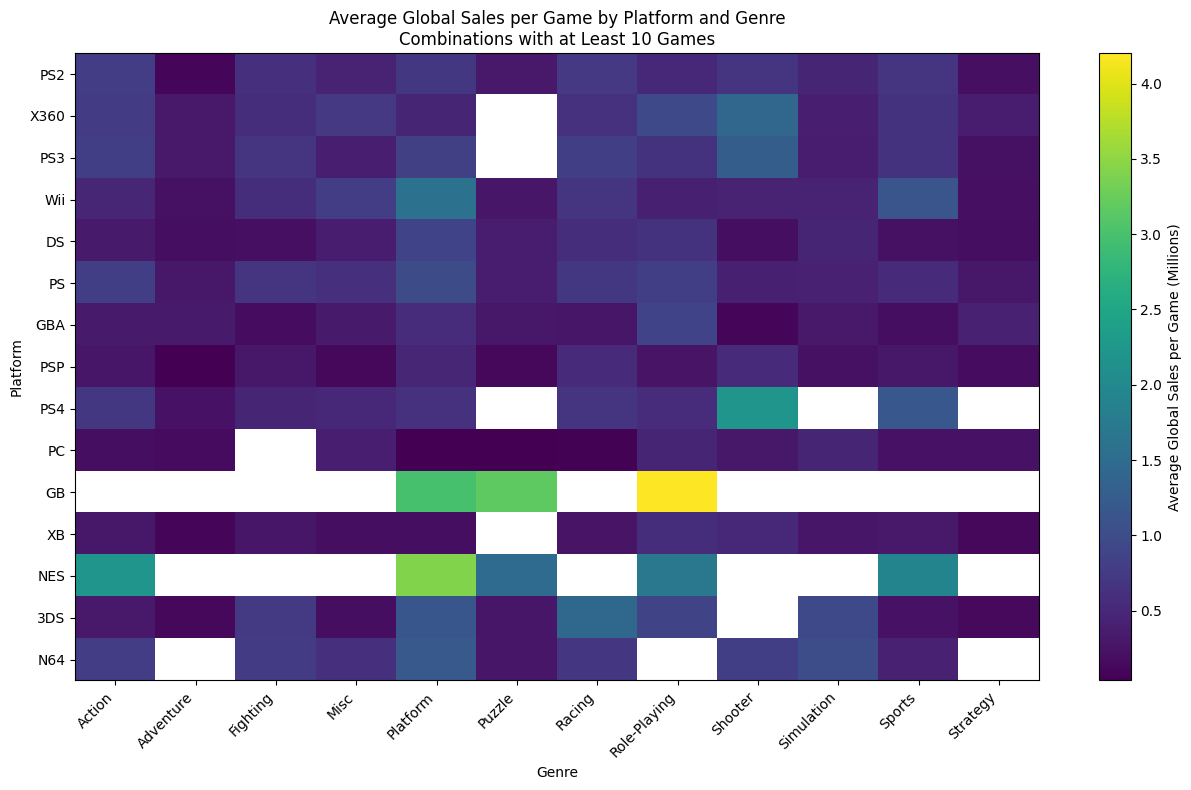

In [15]:
# Plot the average-sales heatmap
fig, ax = plt.subplots(figsize=(13, 8))

heatmap = ax.imshow(
    average_sales_filtered.values,
    aspect="auto"
)

ax.set_xticks(range(len(average_sales_filtered.columns)))
ax.set_xticklabels(
    average_sales_filtered.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(average_sales_filtered.index)))
ax.set_yticklabels(average_sales_filtered.index)

ax.set_title(
    f"Average Global Sales per Game by Platform and Genre\n"
    f"Combinations with at Least {minimum_games} Games"
)
ax.set_xlabel("Genre")
ax.set_ylabel("Platform")

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Average Global Sales per Game (Millions)")

plt.tight_layout()
plt.show()

### Key Takeaway

Average sales per game varied sharply across platform–genre combinations. Game Boy Role-Playing stands out as the strongest pairing at roughly **4.2 million sales per game**, while NES Platform and Game Boy Platform also performed very strongly. More recent combinations such as PS4 Shooter and Xbox One Shooter were successful, but their average sales were still below the leading older Nintendo pairings. The white cells represent combinations with fewer than 10 games, so they were excluded from the comparison.

## 7. Genre Composition of Major Platforms

The following analysis examines the genre composition of the largest platforms.

Rather than comparing raw sales alone, each genre's sales are converted into a percentage of the platform's total global sales.

This shows which genres contributed most strongly to each platform and makes platforms of different sizes easier to compare.

In [16]:
# Select the 10 platforms with the greatest total global sales
major_platforms = (
    analysis_df
    .groupby("platform")["global_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

major_platform_data = analysis_df[
    analysis_df["platform"].isin(major_platforms)
].copy()

# Calculate total sales for each platform-genre combination
platform_genre_sales = (
    major_platform_data
    .groupby(["platform", "genre"], as_index=False)
    .agg(
        total_global_sales=("global_sales", "sum")
    )
)

# Calculate total sales for each platform
platform_totals = (
    platform_genre_sales
    .groupby("platform")["total_global_sales"]
    .transform("sum")
)

# Calculate each genre's percentage of its platform's total sales
platform_genre_sales["sales_share"] = (
    platform_genre_sales["total_global_sales"]
    / platform_totals
    * 100
)

platform_genre_sales.head()

,platform,genre,total_global_sales,sales_share
0,DS,Action,114.16,13.945420
1,DS,Adventure,47.15,5.759693
2,DS,Fighting,7.20,0.879529
3,DS,Misc,137.67,16.817327
4,DS,Platform,77.40,9.454936


In [17]:
# Create a platform-by-genre table using percentage of platform sales
sales_share_pivot = (
    platform_genre_sales
    .pivot(
        index="platform",
        columns="genre",
        values="sales_share"
    )
    .fillna(0)
)

# Keep platforms ordered by total global sales
sales_share_pivot = sales_share_pivot.loc[major_platforms]

sales_share_pivot.round(2)

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
platform,,,,,,,,,,,,
PS2,22.09,1.72,7.23,8.00,5.85,0.48,12.50,7.42,8.78,3.43,21.29,1.22
X360,24.72,1.57,3.88,9.21,1.17,0.07,6.72,7.42,28.59,1.45,14.17,1.01
PS3,32.02,2.41,5.45,4.84,3.14,0.05,7.70,7.93,20.62,1.13,14.21,0.50
Wii,12.14,2.01,2.62,23.90,9.97,1.72,6.73,1.55,2.90,4.03,31.87,0.57
DS,13.95,5.76,0.88,16.82,9.45,10.25,4.71,15.46,1.00,16.05,3.87,1.80
PS,17.29,2.86,9.99,6.17,8.83,1.66,14.15,10.76,5.40,3.48,16.43,2.98
GBA,17.75,3.96,1.38,9.33,25.55,3.96,6.15,21.01,1.18,1.93,5.37,2.44
PSP,21.48,3.66,7.50,4.70,5.92,1.89,11.91,16.80,6.78,2.15,13.68,3.53
PS4,31.31,1.69,2.89,2.66,2.52,0.01,4.15,9.26,27.09,0.28,18.01,0.15


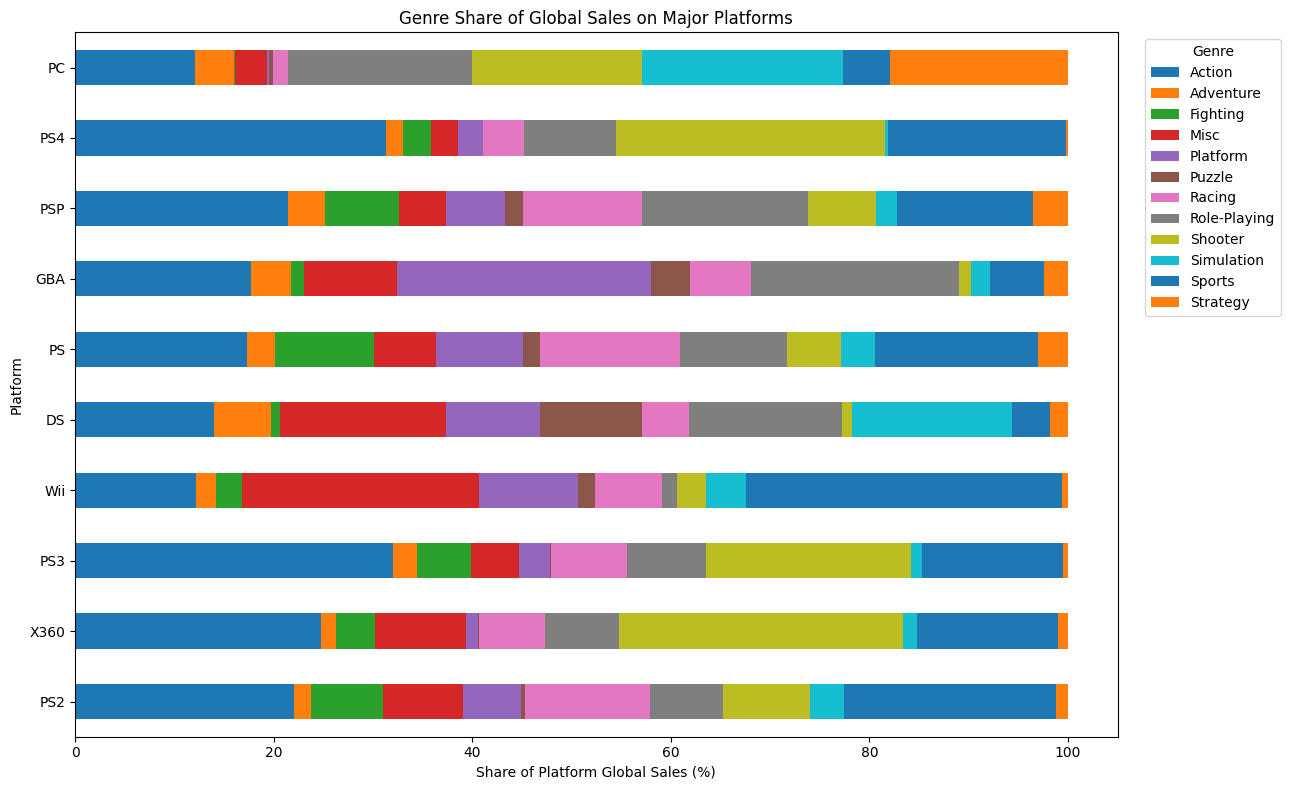

In [18]:
# Plot a 100% stacked horizontal bar chart
ax = sales_share_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(13, 8)
)

ax.set_title("Genre Share of Global Sales on Major Platforms")
ax.set_xlabel("Share of Platform Global Sales (%)")
ax.set_ylabel("Platform")
ax.legend(
    title="Genre",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Key Takeaway

The genre mix differs noticeably across major platforms. Sports accounts for the largest share of Wii sales, while Shooter contributes a particularly large share on the Xbox 360 and PS4. Action is one of the most consistently important genres across several systems, especially the PS3 and PS4, whereas platforms such as the DS, GBA, and PSP show a more distributed sales mix across multiple genres. This indicates that some platforms were strongly associated with a dominant genre, while others had a broader and more balanced genre profile.

## 8. Leading Genre on Each Major Platform

The leading genre on each major platform is identified using total global sales.

This allows the analysis to determine whether the same genres dominated across platforms or whether different platforms were associated with different genre strengths.

In [19]:
# Rank genres within each platform by total global sales
platform_genre_ranking = (
    platform_genre_sales
    .sort_values(
        ["platform", "total_global_sales"],
        ascending=[True, False]
    )
)

# Select the highest-selling genre for each platform
leading_genre_by_platform = (
    platform_genre_ranking
    .groupby("platform", as_index=False)
    .first()
)

# Calculate the number of games in each winning combination
leading_genre_counts = (
    major_platform_data
    .groupby(["platform", "genre"])
    .size()
    .reset_index(name="game_count")
)

leading_genre_by_platform = leading_genre_by_platform.merge(
    leading_genre_counts,
    on=["platform", "genre"],
    how="left"
)

# Calculate average sales for the leading genre on each platform
leading_genre_averages = (
    major_platform_data
    .groupby(["platform", "genre"], as_index=False)
    .agg(
        average_global_sales=("global_sales", "mean")
    )
)

leading_genre_by_platform = leading_genre_by_platform.merge(
    leading_genre_averages,
    on=["platform", "genre"],
    how="left"
)

leading_genre_by_platform = (
    leading_genre_by_platform
    .sort_values("total_global_sales", ascending=False)
)

leading_genre_by_platform[
    [
        "platform",
        "genre",
        "game_count",
        "total_global_sales",
        "average_global_sales",
        "sales_share"
    ]
].round(2)

,platform,genre,game_count,total_global_sales,average_global_sales,sales_share
5,PS3,Action,373,304.02,0.82,32.02
8,Wii,Sports,256,289.95,1.13,31.87
9,X360,Shooter,197,277.23,1.41,28.59
4,PS2,Action,345,272.43,0.79,22.09
0,DS,Misc,389,137.67,0.35,16.82
3,PS,Action,154,125.74,0.82,17.29
6,PS4,Action,122,87.06,0.71,31.31
1,GBA,Platform,139,78.08,0.56,25.55
7,PSP,Action,217,62.66,0.29,21.48
2,PC,Simulation,112,51.73,0.46,20.31


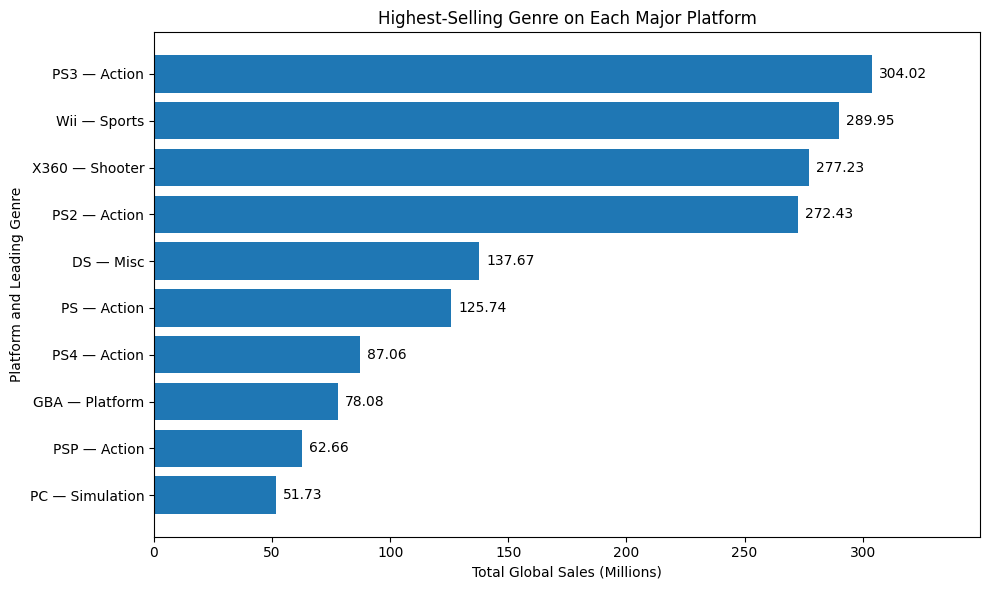

In [20]:
# Prepare labels for the chart
leading_plot_data = leading_genre_by_platform.copy()

leading_plot_data["platform_genre"] = (
    leading_plot_data["platform"]
    + " — "
    + leading_plot_data["genre"]
)

leading_plot_data = leading_plot_data.sort_values(
    "total_global_sales",
    ascending=True
)

plt.figure(figsize=(10, 6))

# Store the container returned by plt.barh()
bars = plt.barh(
    leading_plot_data["platform_genre"],
    leading_plot_data["total_global_sales"]
)

# Add values next to each bar
plt.bar_label(bars, fmt="%.2f", padding=5)

plt.title("Highest-Selling Genre on Each Major Platform")
plt.xlabel("Total Global Sales (Millions)")
plt.ylabel("Platform and Leading Genre")

# Extend x-axis limit slightly so the rightmost labels don't get cut off
plt.xlim(0, leading_plot_data["total_global_sales"].max() * 1.15)

plt.tight_layout()
plt.show()

### Key Takeaway

Action was the highest-selling genre on four of the ten major platforms shown: the PS3, PS2, original PlayStation, and PS4. However, other platforms had different leading genres, including Sports on the Wii, Shooter on the Xbox 360, Misc on the DS, Platform on the GBA, and Simulation on PC. This confirms that genre performance was strongly platform-dependent rather than dominated by one genre across every system.

### Top Three Genres on Each Major Platform

The highest-selling genre alone does not show whether a platform had a diverse genre profile.

The following table lists the three genres with the greatest total global sales on each major platform.

In [21]:
# Assign a sales rank to genres within every platform
platform_genre_ranking["genre_rank"] = (
    platform_genre_ranking
    .groupby("platform")["total_global_sales"]
    .rank(
        method="first",
        ascending=False
    )
)

top_three_genres = (
    platform_genre_ranking[
        platform_genre_ranking["genre_rank"] <= 3
    ]
    .sort_values(["platform", "genre_rank"])
    .copy()
)


In [22]:
# Display the top three genres in a more compact format
top_three_genres_display = (
    top_three_genres
    .assign(
        genre_summary=lambda data:
            data["genre"]
            + " ("
            + data["total_global_sales"].round(2).astype(str)
            + "M)"
    )
    .pivot(
        index="platform",
        columns="genre_rank",
        values="genre_summary"
    )
    .rename(
        columns={
            1.0: "First",
            2.0: "Second",
            3.0: "Third"
        }
    )
)

top_three_genres_display

genre_rank,First,Second,Third
platform,,,
DS,Misc (137.67M),Simulation (131.36M),Role-Playing (126.56M)
GBA,Platform (78.08M),Role-Playing (64.21M),Action (54.26M)
PC,Simulation (51.73M),Role-Playing (47.37M),Strategy (45.63M)
PS,Action (125.74M),Sports (119.51M),Racing (102.89M)
PS2,Action (272.43M),Sports (262.64M),Racing (154.21M)
PS3,Action (304.02M),Shooter (195.8M),Sports (134.91M)
PS4,Action (87.06M),Shooter (75.32M),Sports (50.07M)
PSP,Action (62.66M),Role-Playing (49.01M),Sports (39.9M)
Wii,Sports (289.95M),Misc (217.43M),Action (110.48M)


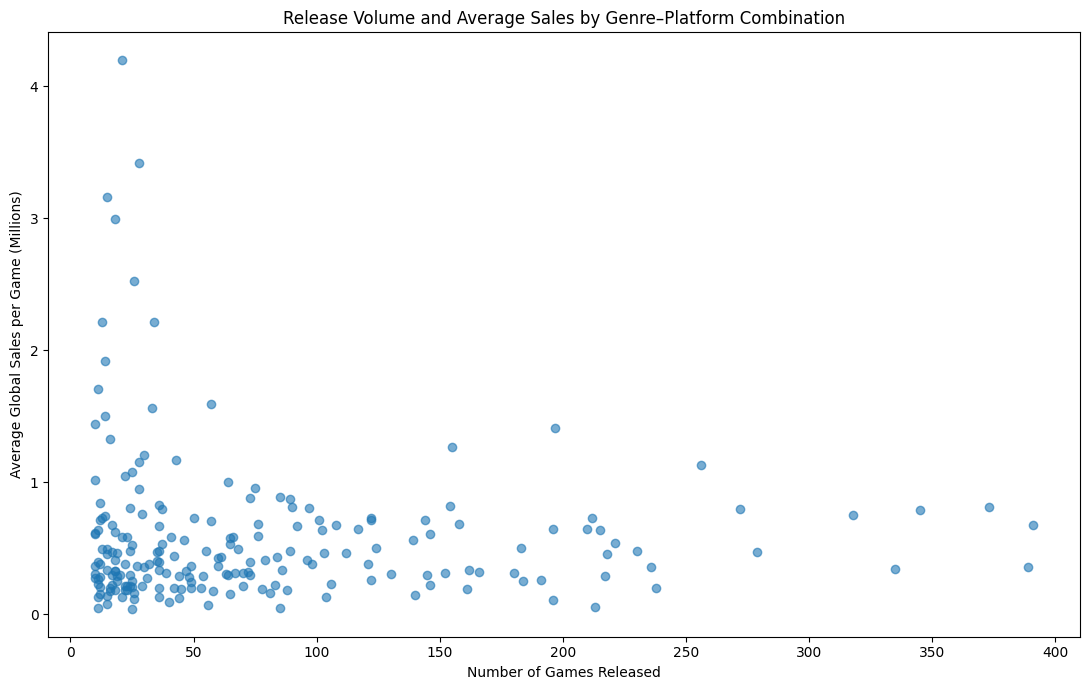

In [23]:
# Use the reliable combinations created earlier
scatter_data = reliable_combinations.copy()

plt.figure(figsize=(11, 7))

plt.scatter(
    scatter_data["game_count"],
    scatter_data["average_global_sales"],
    alpha=0.6
)

plt.title("Release Volume and Average Sales by Genre–Platform Combination")
plt.xlabel("Number of Games Released")
plt.ylabel("Average Global Sales per Game (Millions)")

plt.tight_layout()
plt.show()


### Key Takeaway

The scatter plot shows little visible relationship between release volume and average sales per game. Genre-platform combinations with the highest average sales are concentrated among combinations with relatively few releases, while combinations with hundreds of games generally remain below about **1.5 million average sales per game**. This suggests that releasing more games did not necessarily lead to stronger per-game performance.

In [24]:
# Calculate Pearson correlations between release volume and sales measures
volume_average_correlation = reliable_combinations[
    "game_count"
].corr(
    reliable_combinations["average_global_sales"],
    method="pearson"
)

volume_total_correlation = reliable_combinations[
    "game_count"
].corr(
    reliable_combinations["total_global_sales"],
    method="pearson"
)

print(
    "Pearson correlation between game count and average sales: "
    f"{volume_average_correlation:.3f}"
)

print(
    "Pearson correlation between game count and total sales: "
    f"{volume_total_correlation:.3f}"
)


Pearson correlation between game count and average sales: -0.070
Pearson correlation between game count and total sales: 0.806


The correlations should be interpreted carefully.

A positive relationship between release count and total sales is expected because combinations with more games have more opportunities to accumulate sales.

The relationship between release count and average sales is more informative because it indicates whether larger catalogues were also associated with stronger performance per game.

## 10. Mean and Median Sales Comparison

Average sales can be increased by a small number of blockbuster games.

Median sales provide a more resistant measure of typical performance because they are less affected by extreme values.

Comparing the mean and median helps identify genre-platform combinations whose average may be driven by a limited number of unusually successful titles.

In [25]:
mean_median_comparison = reliable_combinations.copy()

mean_median_comparison["mean_median_difference"] = (
    mean_median_comparison["average_global_sales"]
    - mean_median_comparison["median_global_sales"]
)

mean_median_comparison["mean_to_median_ratio"] = (
    mean_median_comparison["average_global_sales"]
    / mean_median_comparison["median_global_sales"].replace(0, np.nan)
)

mean_median_comparison = mean_median_comparison.sort_values(
    "mean_median_difference",
    ascending=False
)

mean_median_comparison[
    [
        "platform",
        "genre",
        "game_count",
        "average_global_sales",
        "median_global_sales",
        "mean_median_difference",
        "mean_to_median_ratio"
    ]
].head(15).round(2)

,platform,genre,game_count,average_global_sales,median_global_sales,mean_median_difference,mean_to_median_ratio
52,GB,Role-Playing,21,4.20,0.76,3.44,5.53
108,NES,Platform,28,3.42,1.18,2.24,2.90
50,GB,Puzzle,15,3.16,1.15,2.01,2.75
222,SNES,Platform,26,2.53,0.60,1.93,4.24
238,Wii,Platform,57,1.59,0.33,1.26,4.82
19,3DS,Racing,10,1.44,0.21,1.23,6.86
266,X360,Shooter,197,1.41,0.41,1.00,3.43
173,PS4,Shooter,34,2.22,1.26,0.96,1.76
17,3DS,Platform,28,1.15,0.21,0.94,5.48
244,Wii,Sports,256,1.13,0.23,0.90,4.92


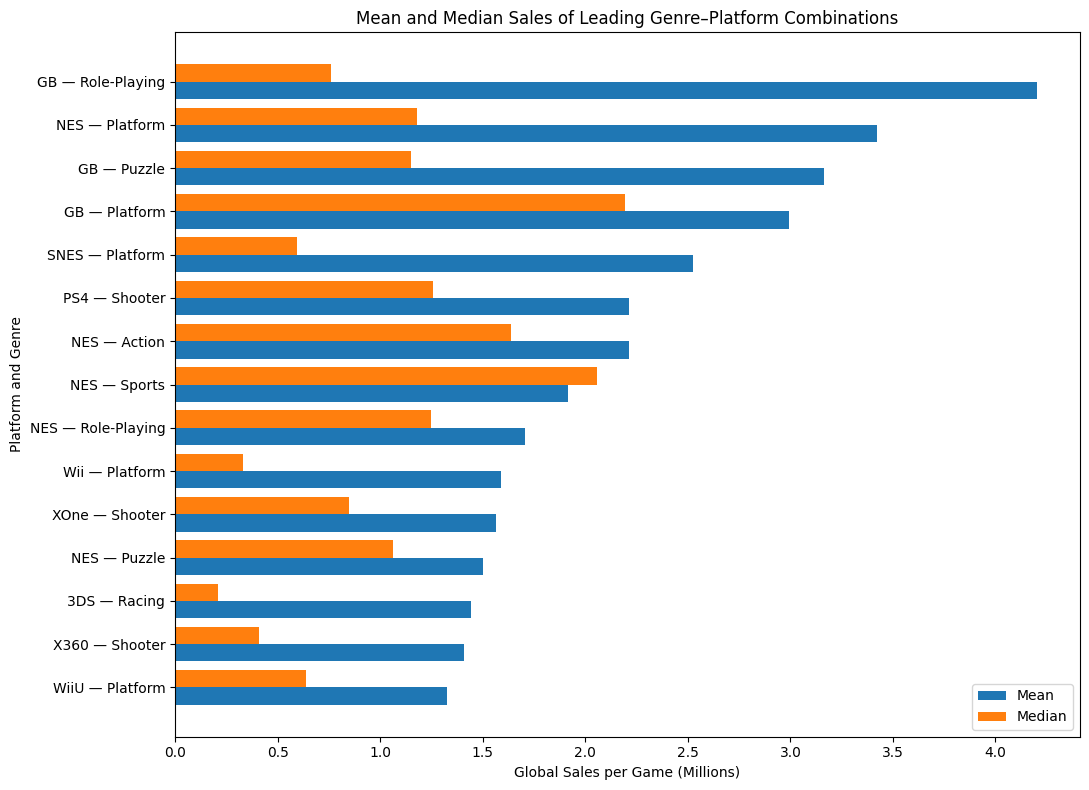

In [26]:
# Select the 15 combinations with the highest average sales
mean_median_plot_data = (
    reliable_combinations
    .sort_values("average_global_sales", ascending=False)
    .head(15)
    .copy()
)

mean_median_plot_data["genre_platform"] = (
    mean_median_plot_data["platform"]
    + " — "
    + mean_median_plot_data["genre"]
)

mean_median_plot_data = mean_median_plot_data.sort_values(
    "average_global_sales",
    ascending=True
)

y_positions = np.arange(len(mean_median_plot_data))

plt.figure(figsize=(11, 8))

plt.barh(
    y_positions - 0.2,
    mean_median_plot_data["average_global_sales"],
    height=0.4,
    label="Mean"
)

plt.barh(
    y_positions + 0.2,
    mean_median_plot_data["median_global_sales"],
    height=0.4,
    label="Median"
)

plt.yticks(
    y_positions,
    mean_median_plot_data["genre_platform"]
)

plt.title("Mean and Median Sales of Leading Genre–Platform Combinations")
plt.xlabel("Global Sales per Game (Millions)")
plt.ylabel("Platform and Genre")
plt.legend()

plt.tight_layout()
plt.show()

### Key Takeaway

For nearly every leading genre-platform combination, the mean sales per game are higher than the median, indicating that a small number of blockbuster titles raised the average above the performance of a typical game. The largest gaps appear for combinations such as Game Boy–Role-Playing, NES–Platform, Game Boy–Puzzle, and SNES–Platform. NES–Sports is a notable exception, where the median slightly exceeds the mean, suggesting a more consistently strong sales distribution with less dependence on extreme high-selling titles.

## 11. Median-Sales Summary

The earlier rankings already compared total sales and average sales. The following table adds the median-sales perspective, which better represents the performance of a typical game when a small number of blockbuster titles may influence the mean.


In [27]:
# Top 10 combinations by median global sales
top_median_sales = (
    reliable_combinations
    .nlargest(10, "median_global_sales")
    [
        [
            "platform",
            "genre",
            "game_count",
            "total_global_sales",
            "average_global_sales",
            "median_global_sales"
        ]
    ]
)

top_median_sales

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
49,GB,Platform,18,53.88,2.993333,2.195
113,NES,Sports,14,26.85,1.917857,2.055
104,NES,Action,13,28.75,2.211538,1.640
173,PS4,Shooter,34,75.32,2.215294,1.260
111,NES,Role-Playing,11,18.78,1.707273,1.250
108,NES,Platform,28,95.78,3.420714,1.180
50,GB,Puzzle,15,47.47,3.164667,1.150
109,NES,Puzzle,14,21.00,1.500000,1.065
289,XOne,Shooter,33,51.61,1.563939,0.850
52,GB,Role-Playing,21,88.24,4.201905,0.760


## Overall Interpretation

The analysis shows that video game genre performance varied substantially across platforms. No single genre was the strongest on every system, and the leading genre-platform combinations changed depending on whether performance was measured using total sales, average sales per game, median sales, or release volume.

In terms of total global sales, PS3–Action was the strongest combination at approximately **304.02 million**, followed by Wii–Sports at **289.95 million** and Xbox 360–Shooter at **277.23 million**. Action appeared repeatedly among the leading combinations and was the highest-selling genre on the PS3, PS2, original PlayStation, and PS4. However, other platforms developed different strengths, including Sports on the Wii, Shooter on the Xbox 360, Misc on the DS, Platform on the GBA, and Simulation on PC.

The platform-level comparisons also showed differences in genre concentration. The Wii depended heavily on Sports sales, while Shooter represented a large share of sales on the Xbox 360 and PS4. Other platforms, including the DS, GBA, and PSP, had sales distributed more evenly across several genres. This suggests that some platforms were strongly associated with a particular audience or genre, while others supported a broader variety of games.

The results changed when performance was measured per game rather than through accumulated sales. Game Boy–Role-Playing achieved the highest average global sales at approximately **4.20 million per game**, while Platform games performed strongly on the NES, Game Boy, and SNES. These combinations were different from those leading in total sales, showing that a large overall sales total did not necessarily mean that the typical game sold more copies.

Release volume also differed from sales efficiency. PS2–Sports had the most releases with **391 games**, followed closely by DS–Misc with **389 games**, but the scatter plot showed little relationship between the number of games released and average sales per game. Combinations with hundreds of releases generally had moderate average sales, while several of the highest per-game averages occurred among combinations with much smaller catalogues. Therefore, producing more games increased the opportunity to accumulate total sales but did not guarantee stronger performance for each individual title.

Finally, the mean was higher than the median for nearly all leading combinations. This indicates that their sales distributions were generally right-skewed, with a small number of blockbuster games increasing the average above the sales of a typical title. NES–Sports was a notable exception because its median slightly exceeded its mean, suggesting more consistent performance across its games.

Overall, the answer to the research question is that **genre performance was strongly dependent on platform**. Different platforms supported different leading genres, and the definition of success changed according to the metric used. Total sales were influenced by both popularity and release volume, average sales identified combinations with strong per-game performance, and median sales revealed whether that performance was typical or driven by a few major hits. Genre and platform should therefore be evaluated together rather than as independent factors.
